# Pertemuan 04 - Classification (Logistic Regression & Decision Tree)

| | |
|---|---|
| **Nama** | Andre Firmansyah |
| **NIM** | 105841101123 |
| **Mata Kuliah** | Machine Learning |
| **Topik** | Classification |
| **Dataset** | Breast Cancer Wisconsin |

---
## 🎯 Tujuan

Pada pertemuan ini, tujuan yang ingin dicapai adalah:
1. Memahami perbedaan antara regresi dan klasifikasi dalam machine learning.
2. Melatih model **Logistic Regression** dan **Decision Tree** menggunakan dataset Breast Cancer Wisconsin.
3. Menampilkan **confusion matrix** untuk setiap model.
4. Membandingkan performa kedua model menggunakan metrik **accuracy, precision, recall, dan F1-score**.
5. Menyimpulkan model mana yang lebih baik beserta alasannya.

---
##  Langkah Kerja

Berikut adalah alur pengerjaan notebook ini:
1. Import semua library yang dibutuhkan
2. Memuat dan mengeksplorasi dataset Breast Cancer
3. Membagi data menjadi data latih dan data uji
4. Melatih model Logistic Regression dan menampilkan hasil evaluasinya
5. Melatih model Decision Tree dan menampilkan hasil evaluasinya
6. Membandingkan kedua model dalam satu tabel
7. Menarik kesimpulan berdasarkan hasil evaluasi

---
##  Import Library

Langkah pertama adalah mengimpor semua library yang akan digunakan selama praktikum. NumPy dan Pandas digunakan untuk mengolah data, Matplotlib dan Seaborn digunakan untuk membuat visualisasi confusion matrix, sedangkan modul-modul dari Scikit-learn digunakan untuk memuat dataset, membangun model klasifikasi, dan menghitung metrik evaluasi.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

---
## 1. Memuat dan Mengeksplorasi Dataset

Dataset yang digunakan adalah **Breast Cancer Wisconsin**, sebuah dataset medis yang sudah tersedia langsung di Scikit-learn. Dataset ini berisi 569 data hasil pemeriksaan sel tumor dengan 30 fitur seperti radius, tekstur, keliling, dan luas sel, serta 2 kelas target yaitu **malignant** (ganas) dan **benign** (jinak). Tujuan klasifikasi ini adalah memprediksi apakah suatu tumor termasuk ganas atau jinak berdasarkan hasil pengukuran tersebut.

In [2]:
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

df = pd.DataFrame(X, columns=cancer.feature_names)
df['Target'] = y
df['Diagnosis'] = ['benign' if i == 1 else 'malignant' for i in y]

print(f'Jumlah data  : {X.shape[0]}')
print(f'Jumlah fitur : {X.shape[1]}')
print(f'Kelas        : {list(cancer.target_names)}')
print(f'Distribusi kelas:')
print(df['Diagnosis'].value_counts())
print()
print('5 baris pertama dataset:')
df[['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'Diagnosis']].head()

Jumlah data  : 569
Jumlah fitur : 30
Kelas        : [np.str_('malignant'), np.str_('benign')]
Distribusi kelas:
Diagnosis
benign       357
malignant    212
Name: count, dtype: int64

5 baris pertama dataset:


,mean radius,mean texture,mean perimeter,mean area,Diagnosis
0,17.99,10.38,122.80,1001.0,malignant
1,20.57,17.77,132.90,1326.0,malignant
2,19.69,21.25,130.00,1203.0,malignant
3,11.42,20.38,77.58,386.1,malignant
4,20.29,14.34,135.10,1297.0,malignant


Dari output di atas terlihat bahwa dataset Breast Cancer memiliki 569 data dengan 30 fitur dan 2 kelas target. Dataset ini cukup tidak seimbang karena jumlah kasus benign lebih banyak dibanding malignant, namun masih dalam batas yang wajar untuk dilatih langsung tanpa perlu penanganan khusus.

### Pembagian Data

Data dibagi menjadi data latih sebanyak 80% dan data uji sebanyak 20%. Parameter random_state=42 digunakan agar pembagian data selalu konsisten setiap kali kode dijalankan ulang.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Jumlah data latih : {len(X_train)}')
print(f'Jumlah data uji   : {len(X_test)}')

Jumlah data latih : 455
Jumlah data uji   : 114


---
## 2. Logistic Regression

Logistic Regression adalah model klasifikasi yang bekerja dengan menghitung probabilitas suatu data termasuk ke dalam kelas tertentu. Meskipun namanya mengandung kata "regression", model ini digunakan untuk klasifikasi bukan prediksi nilai kontinu. Pada kasus ini, model akan menghitung probabilitas apakah suatu tumor termasuk ganas atau jinak berdasarkan 30 fitur yang ada. Parameter max_iter=1000 ditambahkan agar model memiliki cukup iterasi untuk mencapai konvergensi sempurna tanpa memunculkan warning.

### Pelatihan Model

In [4]:
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

print('Model Logistic Regression berhasil dilatih.')

Model Logistic Regression berhasil dilatih.


c:\Users\andre\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Confusion Matrix Logistic Regression

Confusion matrix menampilkan perbandingan antara kelas yang diprediksi model dengan kelas yang sebenarnya. Pada kasus medis seperti ini, confusion matrix sangat penting karena kita perlu tahu seberapa banyak kasus tumor ganas yang salah diprediksi sebagai jinak (false negative), karena kesalahan ini bisa berakibat fatal.

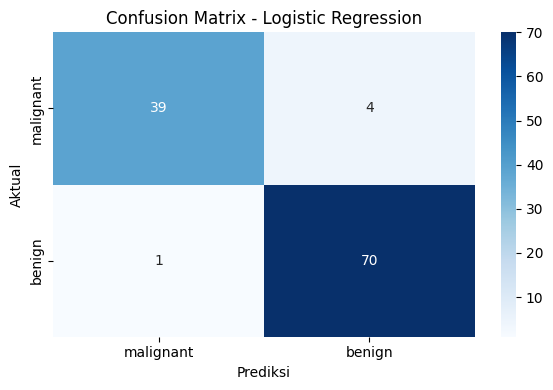

In [5]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

### Evaluasi Logistic Regression

Setelah confusion matrix ditampilkan, langkah berikutnya adalah menghitung metrik evaluasi secara lengkap. Pada konteks medis, nilai recall menjadi sangat penting karena recall mengukur seberapa banyak kasus positif (ganas) yang berhasil terdeteksi dengan benar oleh model.

In [6]:
acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, average='weighted')
rec_lr  = recall_score(y_test, y_pred_lr, average='weighted')
f1_lr   = f1_score(y_test, y_pred_lr, average='weighted')

print('=== Evaluasi Logistic Regression ===')
print(f'Accuracy  : {acc_lr:.4f}')
print(f'Precision : {prec_lr:.4f}')
print(f'Recall    : {rec_lr:.4f}')
print(f'F1-Score  : {f1_lr:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_lr, target_names=cancer.target_names))

=== Evaluasi Logistic Regression ===
Accuracy  : 0.9561
Precision : 0.9569
Recall    : 0.9561
F1-Score  : 0.9558

Classification Report:
              precision    recall  f1-score   support

   malignant       0.97      0.91      0.94        43
      benign       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



---
## 3. Decision Tree

Decision Tree adalah model klasifikasi yang bekerja dengan membuat serangkaian aturan if-else berbentuk pohon keputusan. Model ini memecah data secara bertahap berdasarkan fitur yang paling informatif hingga mencapai keputusan akhir. Kelebihan Decision Tree adalah mudah diinterpretasikan karena kita bisa menelusuri jalur keputusan yang diambil model. Parameter max_depth=3 digunakan untuk membatasi kedalaman pohon agar tidak terjadi overfitting.

### Pelatihan Model

In [7]:
model_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)

print('Model Decision Tree berhasil dilatih.')

Model Decision Tree berhasil dilatih.


### Confusion Matrix Decision Tree

Confusion matrix untuk Decision Tree ditampilkan dengan warna hijau agar mudah dibedakan secara visual dari confusion matrix Logistic Regression sebelumnya. Perbandingan kedua confusion matrix akan memperlihatkan di kelas mana masing-masing model lebih sering membuat kesalahan.

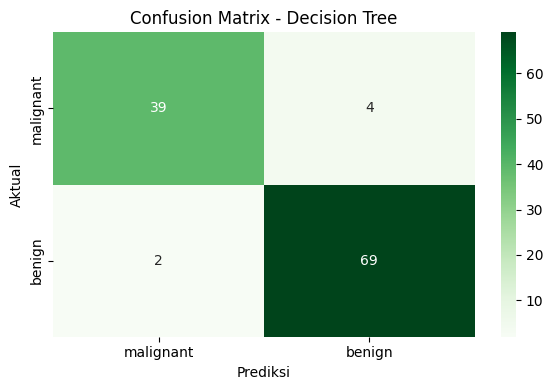

In [8]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

### Evaluasi Decision Tree

Metrik evaluasi yang sama juga dihitung untuk model Decision Tree agar perbandingan antar model bisa dilakukan secara adil dan objektif menggunakan skala pengukuran yang sama.

In [9]:
acc_dt  = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, average='weighted')
rec_dt  = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt   = f1_score(y_test, y_pred_dt, average='weighted')

print('=== Evaluasi Decision Tree ===')
print(f'Accuracy  : {acc_dt:.4f}')
print(f'Precision : {prec_dt:.4f}')
print(f'Recall    : {rec_dt:.4f}')
print(f'F1-Score  : {f1_dt:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_dt, target_names=cancer.target_names))

=== Evaluasi Decision Tree ===
Accuracy  : 0.9474
Precision : 0.9475
Recall    : 0.9474
F1-Score  : 0.9471

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.91      0.93        43
      benign       0.95      0.97      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



---
## 4. Perbandingan Kedua Model

Setelah kedua model dievaluasi secara terpisah, langkah terakhir adalah membandingkan seluruh metrik evaluasi dalam satu tabel agar perbedaan performa antar model dapat terlihat dengan jelas dan mudah dibaca.

In [10]:
perbandingan = pd.DataFrame({
    'Model'     : ['Logistic Regression', 'Decision Tree'],
    'Accuracy'  : [acc_lr, acc_dt],
    'Precision' : [prec_lr, prec_dt],
    'Recall'    : [rec_lr, rec_dt],
    'F1-Score'  : [f1_lr, f1_dt]
})

print('Tabel Perbandingan Metrik Evaluasi:')
perbandingan

Tabel Perbandingan Metrik Evaluasi:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.956140,0.956905,0.956140,0.955801
1,Decision Tree,0.947368,0.947474,0.947368,0.947107


---
##  Kesimpulan

Berdasarkan hasil praktikum klasifikasi menggunakan dataset Breast Cancer Wisconsin, dapat disimpulkan beberapa hal:

1. Kedua model yaitu **Logistic Regression** dan **Decision Tree** mampu melakukan klasifikasi tumor ganas dan jinak dengan performa yang cukup baik.

2. **Logistic Regression** cenderung menghasilkan performa yang lebih stabil karena model ini menghitung probabilitas setiap kelas secara matematis, sehingga lebih tahan terhadap variasi data.

3. **Decision Tree** dengan max_depth=3 menghasilkan pohon keputusan yang sederhana dan mudah diinterpretasikan, namun perlu pembatasan kedalaman agar tidak overfitting.

4. Pada konteks medis seperti deteksi kanker, nilai **recall** menjadi metrik yang paling kritis karena kesalahan memprediksi tumor ganas sebagai jinak (false negative) dapat berakibat fatal bagi pasien.

5. Secara keseluruhan, model dengan nilai accuracy, precision, recall, dan F1-score yang lebih tinggi adalah model yang lebih direkomendasikan untuk digunakan dalam kasus klasifikasi ini.